In [51]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.linear_model import LassoCV
from scipy.stats import mstats
import lightgbm as lgb
import optuna
import joblib
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── paths ──────────────────────────────────────────────────────────────────
DATA_DIR   = r"Optiver"
DENORM_DIR = r"Optiver\individual_book_train_denorm"

OUTPUT_PATH      = os.path.join(DATA_DIR, "model_ready.parquet")
TRAIN_RAW_PATH   = os.path.join(DATA_DIR, "train_data.parquet")
TEST_RAW_PATH    = os.path.join(DATA_DIR, "test_data.parquet")
TRAIN_SCALED_PATH = os.path.join(DATA_DIR, "train_scaled.parquet")
TEST_SCALED_PATH  = os.path.join(DATA_DIR, "test_scaled.parquet")

CLUSTER_CSV      = os.path.join(DATA_DIR, "stock_clusters.csv")
CLUSTER_SCALER   = os.path.join(DATA_DIR, "cluster_scaler.pkl")
CLUSTER_KMEANS   = os.path.join(DATA_DIR, "cluster_kmeans.pkl")
FEATURE_SCALER   = os.path.join(DATA_DIR, "feature_scaler.pkl")

# ── windowing ──────────────────────────────────────────────────────────────
OBS_SECONDS  = 480
TARGET_START = 480

# ── features ───────────────────────────────────────────────────────────────
FEATURE_COLS = (
    [f'log_rv_lag_{i}' for i in range(1, 17)] +
    ['log_rv_short', 'log_rv_long'] +
    ['rv_8min', 'rv_ratio', 'log_rv_ratio', 'rv_acceleration'] +
    ['log_ret_std', 'log_ret_skew', 'log_ret_kurt'] +
    ['mean_spread', 'max_spread', 'mean_volume', 'signed_volume'] +
    ['mean_depth_imbalance', 'std_depth_imbalance'] +
    ['wap_range', 'zero_ret_frac']
)
# FEATURE_COLS = ( TBD....
#     [f'log_rv_lag_{i}' for i in range(1, 17)] +
#     ['log_rv_short', 'log_rv_long'] +
#     ['rv_8min', 'rv_ratio', 'log_rv_ratio', 'rv_acceleration'] +
#     ['log_ret_std', 'log_ret_kurt'] +                          # dropped log_ret_skew
#     ['mean_spread', 'max_spread', 'mean_volume'] +             # dropped signed_volume
#     ['mean_depth_imbalance', 'std_depth_imbalance'] +
#     ['wap_range', 'zero_ret_frac'] +
#     ['stock_rv_zscore', 'stock_spread_zscore']                 # new
# )

CLUSTER_FEATURES = [
    'rv_8min_med', 'rv_8min_std',
    'mean_spread_med', 'mean_volume_med_wins'
]

TARGET     = 'log_rv_ratio_target'
TARGET_RAW = 'target_rv'
GROUPS     = 'time_id'
K_FINAL    = 3

print("Constants loaded")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Paths: {DATA_DIR}")

Constants loaded
Features: 33
Paths: Optiver


## Feature engineering and target selection

In [2]:
def process_stock(path):
    stock_id = int(os.path.basename(path).split('_')[1].split('.')[0])
    try:
        df = pd.read_csv(path)
        df.sort_values(['time_id', 'seconds_in_bucket'], inplace=True)

        df_obs    = df[df['seconds_in_bucket'] < OBS_SECONDS].copy()
        df_target = df[df['seconds_in_bucket'] >= TARGET_START].copy()

        df_obs['log_wap']    = np.log(df_obs['wap'])
        df_target['log_wap'] = np.log(df_target['wap'])

        df_obs['log_ret']    = df_obs.groupby('time_id')['log_wap'].diff()
        df_target['log_ret'] = df_target.groupby('time_id')['log_wap'].diff()

        # ── 30-second interval RV lags ────────────────────────────────────
        df_obs['interval'] = (df_obs['seconds_in_bucket'] // 30).astype(int)
        df_obs['interval'] = df_obs['interval'].clip(upper=15)

        interval_rv = (
            df_obs.groupby(['time_id', 'interval'])['log_ret']
                  .apply(lambda x: np.sqrt(np.sum(x**2)))
                  .unstack(level='interval')
        )
        interval_rv.columns = [f'rv_lag_{int(c)+1}' for c in interval_rv.columns]
        interval_rv = interval_rv.fillna(0)

        for col in interval_rv.columns:
            interval_rv[f'log_{col}'] = np.log(interval_rv[col].clip(lower=1e-10))

        # ── HAR aggregates ────────────────────────────────────────────────
        interval_rv['log_rv_short'] = interval_rv[[f'log_rv_lag_{i}' for i in range(1, 4)]].mean(axis=1)
        interval_rv['log_rv_long']  = interval_rv[[f'log_rv_lag_{i}' for i in range(1, 17)]].mean(axis=1)

        # ── target RV ─────────────────────────────────────────────────────
        target_rv = (df_target.groupby('time_id')['log_ret']
                              .apply(lambda x: np.sqrt(np.sum(x**2)))
                              .rename('target_rv'))

        # ── session-level RV features ─────────────────────────────────────
        rv_60s  = (df_obs[df_obs['seconds_in_bucket'] >= 420]
                       .groupby('time_id')['log_ret']
                       .apply(lambda x: np.sqrt(np.sum(x**2))))
        rv_8min = (df_obs.groupby('time_id')['log_ret']
                         .apply(lambda x: np.sqrt(np.sum(x**2)))
                         .rename('rv_8min'))

        # ── microstructure features ───────────────────────────────────────
        mean_spread   = df_obs.groupby('time_id')['bid_ask_spread'].mean().rename('mean_spread')
        max_spread    = df_obs.groupby('time_id')['bid_ask_spread'].max().rename('max_spread')
        mean_volume   = df_obs.groupby('time_id')['total_volume'].mean().rename('mean_volume')

        df_obs['signed_vol'] = np.sign(df_obs['log_ret']) * df_obs['total_volume']
        signed_volume = df_obs.groupby('time_id')['signed_vol'].sum().rename('signed_volume')

        log_ret_std  = df_obs.groupby('time_id')['log_ret'].std().rename('log_ret_std')
        log_ret_skew = df_obs.groupby('time_id')['log_ret'].skew().rename('log_ret_skew')
        log_ret_kurt = (df_obs.groupby('time_id')['log_ret']
                              .apply(lambda x: x.kurt())
                              .rename('log_ret_kurt'))

        mean_depth = df_obs.groupby('time_id')['depth_imbalance'].mean().rename('mean_depth_imbalance')
        std_depth  = df_obs.groupby('time_id')['depth_imbalance'].std().rename('std_depth_imbalance')

        # ── quietness signals ─────────────────────────────────────────────
        wap_range = (df_obs.groupby('time_id')['wap']
                           .apply(lambda x: np.log(x.max() / x.min() + 1e-8))
                           .rename('wap_range'))

        zero_ret_frac = (df_obs.groupby('time_id')['log_ret']
                                .apply(lambda x: (x.abs() < 1e-10).mean())
                                .rename('zero_ret_frac'))

        # ── combine ───────────────────────────────────────────────────────
        features = pd.concat([
            rv_8min,
            log_ret_std, log_ret_skew, log_ret_kurt,
            mean_spread, max_spread,
            mean_volume, signed_volume,
            mean_depth, std_depth,
            wap_range, zero_ret_frac,
            target_rv
        ], axis=1).reset_index()

        features = features.merge(interval_rv.reset_index(), on='time_id', how='left')

        # ── derived features ──────────────────────────────────────────────
        features['rv_ratio']        = rv_60s.values / (features['rv_8min'].values + 1e-8)
        features['log_rv_ratio']    = np.log(features['rv_ratio'] + 1e-8)
        features['rv_acceleration'] = np.log(rv_60s.values + 1e-8) - np.log(
            features['rv_8min'].values / 8 + 1e-8
        )

        # ── log ratio target ──────────────────────────────────────────────
        features['log_rv_ratio_target'] = np.log(
            np.maximum(features['target_rv'], 1e-8) / (features['rv_8min'] + 1e-8)
        )

        features['stock_id'] = stock_id
        return features

    except Exception as e:
        print(f"Failed on stock_{stock_id}: {e}")
        return pd.DataFrame()


files = glob.glob(os.path.join(DENORM_DIR, "stock_*.csv"))
print(f"Processing {len(files)} stocks...")

from joblib import Parallel, delayed
dfs = Parallel(n_jobs=-1, verbose=5)(
    delayed(process_stock)(p) for p in files
)

model_ready = pd.concat(dfs, ignore_index=True)
model_ready.to_parquet(OUTPUT_PATH, index=False)
print(f"Saved model_ready.parquet — shape: {model_ready.shape}")
print(model_ready[['rv_8min', 'log_rv_lag_1', 'log_rv_short', 'log_rv_long',
                    'rv_ratio', 'log_rv_ratio', 'wap_range', 'zero_ret_frac',
                    'target_rv', 'log_rv_ratio_target']].describe())

Processing 112 stocks...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   47.1s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 112 out of 112 | elapsed: 10.6min finished


Saved model_ready.parquet — shape: (428932, 53)
             rv_8min   log_rv_lag_1   log_rv_short    log_rv_long  \
count  428932.000000  428932.000000  428932.000000  428932.000000   
mean        0.003825      -7.427142      -7.425354      -7.477678   
std         0.003302       1.258189       0.999112       0.839617   
min         0.000000     -23.025851     -23.025851     -23.025851   
25%         0.001846      -7.912037      -7.907680      -7.960803   
50%         0.002836      -7.355777      -7.397989      -7.481400   
75%         0.004605      -6.790269      -6.858911      -6.965671   
max         0.078812      -3.223178      -3.466793      -4.283318   

            rv_ratio   log_rv_ratio      wap_range  zero_ret_frac  \
count  428932.000000  428932.000000  428793.000000  428932.000000   
mean        0.326705      -1.197523       0.004110       0.450105   
std         0.108153       0.604096       0.003719       0.226234   
min         0.000000     -18.420681       0.000125    

In [4]:
print(model_ready[model_ready['wap_range'].isna()]['stock_id'].value_counts())

stock_id
31    133
80      3
32      1
46      1
89      1
Name: count, dtype: int64


## Test/Train Split and Clustering 


In [3]:
# split by time_id to prevent leakage
model_ready = model_ready.reset_index(drop=True)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(
    model_ready[['stock_id']].values, 
    groups=model_ready['time_id'].values
))

train_data = model_ready.iloc[train_idx]
test_data  = model_ready.iloc[test_idx]

print(f"Train: {len(train_data):,} rows | Test: {len(test_data):,} rows")
print(f"Train time_ids: {train_data['time_id'].nunique()} | Test time_ids: {test_data['time_id'].nunique()}")

train_data.to_parquet(r"Optiver\train_data.parquet", index=False)
test_data.to_parquet(r"Optiver\test_data.parquet", index=False)


Train: 343,146 rows | Test: 85,786 rows
Train time_ids: 3064 | Test time_ids: 766


In [5]:
stock_stats = (
    train_data
    .groupby('stock_id')
    .agg(
        rv_8min_med     = ('rv_8min',    'median'),
        rv_8min_std     = ('rv_8min',    'std'),
        mean_spread_med = ('mean_spread', 'median'),
        mean_volume_med = ('mean_volume', 'median'),
    )
    .reset_index()
)

# winsorise volume to handle stock 31 outlier
stock_stats['mean_volume_med_wins'] = mstats.winsorize(
    stock_stats['mean_volume_med'], limits=[0, 0.02]
).data


print(f"Stock stats shape: {stock_stats.shape}")
print(stock_stats[CLUSTER_FEATURES].describe().round(4))
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(stock_stats[CLUSTER_FEATURES].values)

print("Correlation matrix:")
print(stock_stats[CLUSTER_FEATURES].corr().round(2))


Stock stats shape: (112, 6)
       rv_8min_med  rv_8min_std  mean_spread_med  mean_volume_med_wins
count     112.0000     112.0000         112.0000              112.0000
mean        0.0030       0.0029           0.0005             1561.9186
std         0.0011       0.0009           0.0003             2878.7623
min         0.0011       0.0011           0.0000              144.4396
25%         0.0022       0.0023           0.0003              376.4971
50%         0.0028       0.0028           0.0005              574.8010
75%         0.0035       0.0035           0.0007             1012.3776
max         0.0070       0.0054           0.0019            15617.4927
Correlation matrix:
                      rv_8min_med  rv_8min_std  mean_spread_med  \
rv_8min_med                  1.00         0.86             0.88   
rv_8min_std                  0.86         1.00             0.86   
mean_spread_med              0.88         0.86             1.00   
mean_volume_med_wins        -0.30        -0.3

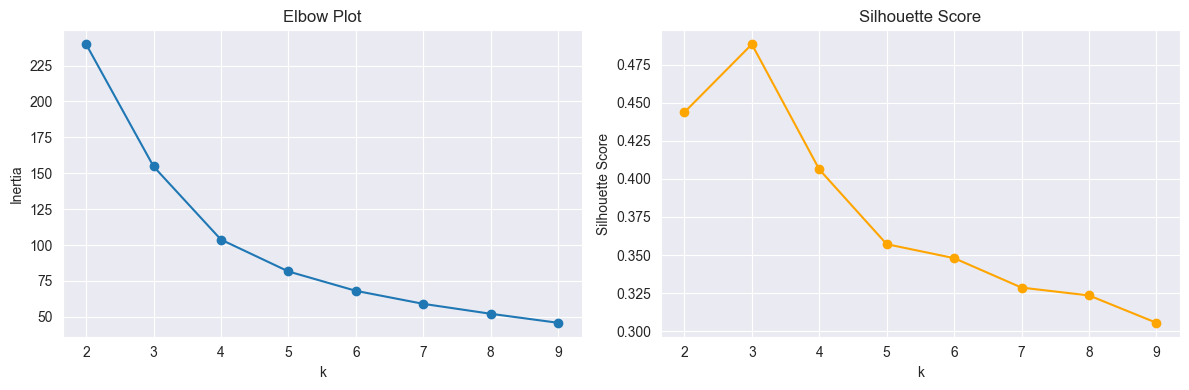

k=2  silhouette=0.4438
k=3  silhouette=0.4884
k=4  silhouette=0.4062
k=5  silhouette=0.3571
k=6  silhouette=0.3479
k=7  silhouette=0.3286
k=8  silhouette=0.3235
k=9  silhouette=0.3055


In [6]:
inertias    = []
silhouettes = []
K_range     = range(2, 10)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Plot')

axes[1].plot(K_range, silhouettes, marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()

for k, s in zip(K_range, silhouettes):
    print(f"k={k}  silhouette={s:.4f}")

Cluster sizes:
cluster
0    38
1    69
2     5
Name: count, dtype: int64

Cluster means:
         rv_8min_med  rv_8min_std  mean_spread_med  mean_volume_med_wins
cluster                                                                 
0             0.0041       0.0039           0.0009              410.7960
1             0.0024       0.0025           0.0003             1334.2925
2             0.0022       0.0022           0.0005            13451.6896


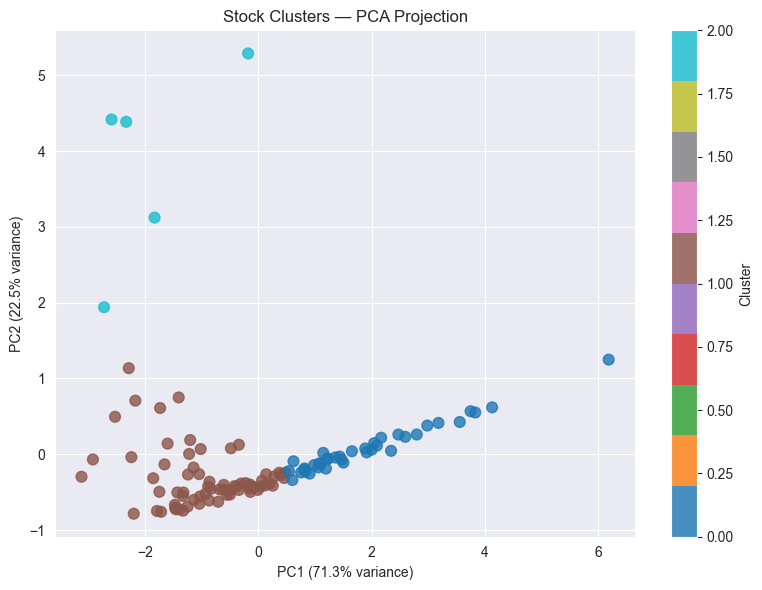

In [52]:
K_FINAL = 3

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
stock_stats['cluster'] = km_final.fit_predict(X_scaled)

print("Cluster sizes:")
print(stock_stats['cluster'].value_counts().sort_index())
print("\nCluster means:")
print(stock_stats.groupby('cluster')[CLUSTER_FEATURES].mean().round(4))

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=stock_stats['cluster'],
                      cmap='tab10', s=60, alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Stock Clusters — PCA Projection')
plt.tight_layout()
plt.show()


In [53]:
# save cluster labels
stock_clusters = stock_stats[['stock_id', 'cluster']]
stock_clusters.to_csv(r"Optiver\stock_clusters.csv", index=False)

# save fitted scaler and kmeans for inference time
joblib.dump(scaler,   r"Optiver\cluster_scaler.pkl")
joblib.dump(km_final, r"Optiver\cluster_kmeans.pkl")

# merge cluster labels into model_ready and resave

model_ready = model_ready.drop(columns=[c for c in model_ready.columns 
                                         if c.startswith('cluster')])
model_ready = model_ready.merge(
    stock_clusters[['stock_id', 'cluster']],
    on='stock_id', how='left'
)

# verify
print(model_ready.columns.tolist())
print(model_ready['cluster'].value_counts().sort_index())

# save
train_data = model_ready.iloc[train_idx]
test_data  = model_ready.iloc[test_idx]
train_data.to_parquet(r"Optiver\train_data.parquet", index=False)
test_data.to_parquet(r"Optiver\test_data.parquet", index=False)
model_ready.to_parquet(r"Optiver\model_ready.parquet", index=False)
print(f"Saved — shape: {model_ready.shape}")

['time_id', 'rv_8min', 'log_ret_std', 'log_ret_skew', 'log_ret_kurt', 'mean_spread', 'max_spread', 'mean_volume', 'signed_volume', 'mean_depth_imbalance', 'std_depth_imbalance', 'wap_range', 'zero_ret_frac', 'target_rv', 'rv_lag_1', 'rv_lag_2', 'rv_lag_3', 'rv_lag_4', 'rv_lag_5', 'rv_lag_6', 'rv_lag_7', 'rv_lag_8', 'rv_lag_9', 'rv_lag_10', 'rv_lag_11', 'rv_lag_12', 'rv_lag_13', 'rv_lag_14', 'rv_lag_15', 'rv_lag_16', 'log_rv_lag_1', 'log_rv_lag_2', 'log_rv_lag_3', 'log_rv_lag_4', 'log_rv_lag_5', 'log_rv_lag_6', 'log_rv_lag_7', 'log_rv_lag_8', 'log_rv_lag_9', 'log_rv_lag_10', 'log_rv_lag_11', 'log_rv_lag_12', 'log_rv_lag_13', 'log_rv_lag_14', 'log_rv_lag_15', 'log_rv_lag_16', 'log_rv_short', 'log_rv_long', 'rv_ratio', 'log_rv_ratio', 'rv_acceleration', 'log_rv_ratio_target', 'stock_id', 'cluster']
cluster
0    145513
1    264269
2     19150
Name: count, dtype: int64
Saved — shape: (428932, 54)


## Feature Scaling and Preprocessing

In [54]:
# ── load ──────────────────────────────────────────────────────────────────
train_data = pd.read_parquet(TRAIN_RAW_PATH)
test_data  = pd.read_parquet(TEST_RAW_PATH)

print(f"Train: {train_data.shape} | Test: {test_data.shape}")

# ── save raw columns before any transformation ────────────────────────────
train_data['rv_8min_raw']   = train_data['rv_8min'].copy()
test_data['rv_8min_raw']    = test_data['rv_8min'].copy()
train_data['target_rv_raw'] = train_data['target_rv'].copy()
test_data['target_rv_raw']  = test_data['target_rv'].copy()

# ── log transform all positive features ───────────────────────────────────
LOG_COLS = ['rv_8min', 'mean_spread', 'max_spread', 'mean_volume', 'log_ret_std']

for col in LOG_COLS:
    train_data[col] = np.log(train_data[col] + 1e-8)
    test_data[col]  = np.log(test_data[col]  + 1e-8)

# ── features left as-is (can be negative, no transform needed) ────────────
# rv_ratio, rv_acceleration — already log differences
# log_ret_skew, log_ret_kurt — can be negative
# signed_volume — can be negative
# mean_depth_imbalance, std_depth_imbalance — bounded [-1, 1]

# ── sanity check ──────────────────────────────────────────────────────────
print("\nLog-transformed features:")
print(train_data[LOG_COLS].describe().round(4))
print("\nUntransformed features:")
PASS_COLS = [c for c in FEATURE_COLS if c not in LOG_COLS]
print(train_data[PASS_COLS].describe().round(4))
print(f"\nrv_8min_raw mean:   {train_data['rv_8min_raw'].mean():.6f}  (should be ~0.003829)")
print(f"target_rv_raw mean: {train_data['target_rv_raw'].mean():.6f}  (should be ~0.001739)")
print(f"log_rv_ratio mean:  {train_data[TARGET].mean():.6f}  (should be ~-0.798)")

# ── NaN check and drop ────────────────────────────────────────────────────
nan_mask = train_data[FEATURE_COLS].isna().any(axis=1)
print(f"\nNaN rows: {nan_mask.sum()}")
if nan_mask.sum() > 0:
    print(train_data[nan_mask]['stock_id'].value_counts().head(5))

train_data = train_data.dropna(subset=FEATURE_COLS)
test_data  = test_data.dropna(subset=FEATURE_COLS)
print(f"\nAfter dropna — Train: {train_data.shape} | Test: {test_data.shape}")

# ── save ──────────────────────────────────────────────────────────────────
train_data.to_parquet(TRAIN_SCALED_PATH, index=False)
test_data.to_parquet(TEST_SCALED_PATH,   index=False)
print("Saved train_scaled.parquet and test_scaled.parquet")

Train: (343146, 54) | Test: (85786, 54)

Log-transformed features:
           rv_8min  mean_spread   max_spread  mean_volume  log_ret_std
count  343146.0000  343029.0000  343029.0000  343146.0000  343029.0000
mean       -5.8185      -7.6584      -6.9629       6.6814      -8.8995
std         0.7197       0.8224       0.8534       1.1657       0.6812
min       -18.4207     -10.5399      -9.8956       2.3047     -11.8297
25%        -6.2928      -8.2400      -7.5420       5.9623      -9.3777
50%        -5.8643      -7.7030      -6.9880       6.3758      -8.9494
75%        -5.3803      -7.1109      -6.4229       7.0563      -8.4653
max        -2.5407      -3.9781      -2.9923      14.0189      -5.6255

Untransformed features:
       log_rv_lag_1  log_rv_lag_2  log_rv_lag_3  log_rv_lag_4  log_rv_lag_5  \
count   343146.0000   343146.0000   343146.0000   343146.0000   343146.0000   
mean        -7.4238       -7.4196       -7.4226       -7.4353       -7.4465   
std          1.2582        1.273

## Modelling

In [33]:
# ── load ──────────────────────────────────────────────────────────────────
train_data = pd.read_parquet(TRAIN_SCALED_PATH)
test_data  = pd.read_parquet(TEST_SCALED_PATH)

X_train = train_data[FEATURE_COLS].values
y_train = train_data[TARGET].values
X_test  = test_data[FEATURE_COLS].values
y_test  = test_data[TARGET].values

rv_8min_train_raw = train_data['rv_8min_raw'].values
rv_8min_test_raw  = test_data['rv_8min_raw'].values
rv_true_train     = train_data['target_rv_raw'].values
rv_true_test      = test_data['target_rv_raw'].values
groups_train      = train_data[GROUPS].values

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"rv_8min_raw mean:   {rv_8min_train_raw.mean():.6f}  (should be ~0.003829)")
print(f"target_rv_raw mean: {rv_true_train.mean():.6f}  (should be ~0.001739)")
print(f"y_train mean:       {y_train.mean():.6f}  (should be ~-0.798)")

# ── helpers ───────────────────────────────────────────────────────────────
def rmspe(y_true, y_pred):
    mask   = y_true > 1e-4
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

def qlike(y_true, y_pred):
    ratio = y_true / (y_pred + 1e-4)
    return np.mean(ratio - np.log(ratio + 1e-4) - 1)

def smearing_correction(residuals):
    return np.mean(np.exp(residuals))

def back_transform(log_ratio_pred, rv_8min, delta=1.0):
    return np.exp(log_ratio_pred) * delta * rv_8min

def evaluate(rv_true, rv_pred, label=''):
    mask      = rv_true > 1e-4
    rv_true_m = rv_true[mask]
    rv_pred_m = rv_pred[mask]
    rmspe_val = rmspe(rv_true, rv_pred)
    qlike_val = qlike(rv_true_m, rv_pred_m)
    mae       = np.mean(np.abs(rv_true_m - rv_pred_m))
    rmse      = np.sqrt(mean_squared_error(rv_true_m, rv_pred_m))
    print(f"\n── {label} ──")
    print(f"  RMSPE : {rmspe_val:.6f}")
    print(f"  QLIKE : {qlike_val:.6f}")
    print(f"  MAE   : {mae:.8f}")
    print(f"  RMSE  : {rmse:.8f}")
    return dict(rmspe=rmspe_val, qlike=qlike_val, mae=mae, rmse=rmse)

# ── grouped CV splits ─────────────────────────────────────────────────────
gkf    = GroupKFold(n_splits=5)
splits = list(gkf.split(X_train, y_train, groups=groups_train))
print(f"\nGroupKFold splits ready: {len(splits)}")

X_train: (343029, 33) | X_test: (85764, 33)
rv_8min_raw mean:   0.003830  (should be ~0.003829)
target_rv_raw mean: 0.001740  (should be ~0.001739)
y_train mean:       -0.798217  (should be ~-0.798)

GroupKFold splits ready: 5


### Model 1: Global LightGBM model

In [34]:
def objective(trial):
    params = {
        'objective'         : 'regression',
        'metric'            : 'rmse',
        'verbosity'         : -1,
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves'        : trial.suggest_int('num_leaves', 32, 256),
        'min_child_samples' : trial.suggest_int('min_child_samples', 20, 150),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 0.1, 20.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'n_jobs'            : -1,
        'random_state'      : 42,
    }
    scores = []
    for tr_idx, vl_idx in splits[:3]:
        lgb_tr = lgb.Dataset(X_train[tr_idx], label=y_train[tr_idx])
        lgb_vl = lgb.Dataset(X_train[vl_idx], label=y_train[vl_idx])
        model  = lgb.train(
            params, lgb_tr,
            num_boost_round = 1000,
            valid_sets      = [lgb_vl],
            callbacks       = [lgb.early_stopping(50), lgb.log_evaluation(-1)]
        )
        scores.append(model.best_score['valid_0']['rmse'])
    return np.mean(scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=25, show_progress_bar=True)

print(f"\nBest RMSE: {study.best_value:.6f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/25 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[101]	valid_0's rmse: 0.320723
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[209]	valid_0's rmse: 0.329878
[W 2026-04-26 21:06:10,964] Trial 0 failed with parameters: {'learning_rate': 0.06245338083702363, 'num_leaves': 209, 'min_child_samples': 79, 'subsample': 0.6488303579009741, 'colsample_bytree': 0.6406802592998173, 'reg_alpha': 0.619789006526042, 'reg_lambda': 0.002295627241650233} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\Hp\anaconda3\envs\DATA3888\lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Hp\AppData\Local\Temp\ipykernel_22080\1515219661.py", line 20, in objective
    model  = lgb.train(
  File "C:\Users\Hp\anaconda3\envs\DATA3888\lib\site-packages\lightgbm\engine.py", line 297, in train
    boo

KeyboardInterrupt: 

Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.331458
[200]	valid_0's rmse: 0.329095
[300]	valid_0's rmse: 0.328028
[400]	valid_0's rmse: 0.327396
[500]	valid_0's rmse: 0.327056
[600]	valid_0's rmse: 0.326855
[700]	valid_0's rmse: 0.326752
[800]	valid_0's rmse: 0.326689
[900]	valid_0's rmse: 0.326652
[1000]	valid_0's rmse: 0.326609
[1100]	valid_0's rmse: 0.326598
[1200]	valid_0's rmse: 0.326586
[1300]	valid_0's rmse: 0.326613
Early stopping, best iteration is:
[1215]	valid_0's rmse: 0.326578
Smearing factor: 1.0448

── LightGBM Global — Test ──
  RMSPE : 0.451402
  QLIKE : 0.050921
  MAE   : 0.00038360
  RMSE  : 0.00065859

Log ratio pred std: 0.1125
Log ratio true std: 0.3396
Saved lgb_global.txt
Feature importance (gain):
rv_ratio                11542.935434
log_ret_std             10118.640501
log_ret_kurt             9260.777568
rv_8min                  9200.377060
log_rv_ratio             8543.771591
mean_spread              7445.881074
rv_ac

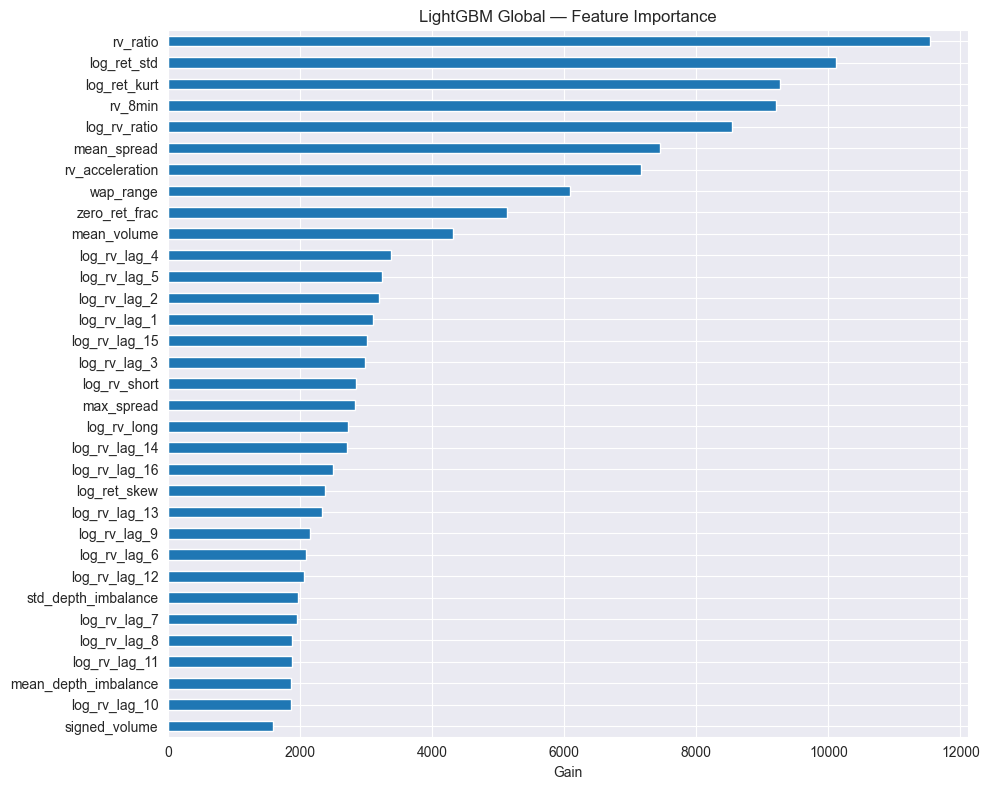

In [35]:
# Best params from tree:
#   learning_rate: 0.02110727179726844
#   num_leaves: 52
#   min_child_samples: 55
#   subsample: 0.6195496469818723
#   colsample_bytree: 0.7811521785697184
#   reg_alpha: 10.618307544916174
#   reg_lambda: 0.6026515758997979
best_params = {
    'learning_rate'     : 0.02110727179726844,
    'num_leaves'        : 52,
    'min_child_samples' : 55,
    'subsample'         : 0.6195496469818723,
    'colsample_bytree'  : 0.7811521785697184,
    'reg_alpha'         : 10.618307544916174,
    'reg_lambda'        : 0.6026515758997979,
    'objective'         : 'regression',
    'metric'            : 'rmse',
    'verbosity'         : -1,
    'n_jobs'            : -1,
    'random_state'      : 42,
}

tr_idx, vl_idx = splits[-1]
lgb_tr = lgb.Dataset(X_train[tr_idx], label=y_train[tr_idx])
lgb_vl = lgb.Dataset(X_train[vl_idx], label=y_train[vl_idx])

lgb_global = lgb.train(
    best_params, lgb_tr,
    num_boost_round = 3000,
    valid_sets      = [lgb_vl],
    callbacks       = [lgb.early_stopping(100), lgb.log_evaluation(100)]
)

# smearing
lgb_log_pred_train = lgb_global.predict(X_train)
residuals_lgb      = y_train - lgb_log_pred_train
delta_lgb          = smearing_correction(residuals_lgb)
print(f"Smearing factor: {delta_lgb:.4f}")

# predict and evaluate
lgb_log_pred_test = lgb_global.predict(X_test)
lgb_rv_test       = back_transform(lgb_log_pred_test, rv_8min_test_raw, delta_lgb)
lgb_metrics       = evaluate(rv_true_test, lgb_rv_test, 'LightGBM Global — Test')

# prediction compression check
print(f"\nLog ratio pred std: {lgb_log_pred_test.std():.4f}")
print(f"Log ratio true std: {y_test.std():.4f}")

lgb_global.save_model(os.path.join(DATA_DIR, "lgb_global.txt"))
print("Saved lgb_global.txt")

importance = pd.Series(
    lgb_global.feature_importance(importance_type='gain'),
    index=FEATURE_COLS
).sort_values(ascending=False)

print("Feature importance (gain):")
print(importance.to_string())

plt.figure(figsize=(10, 8))
importance.sort_values().plot(kind='barh')
plt.xlabel('Gain')
plt.title('LightGBM Global — Feature Importance')
plt.tight_layout()
plt.show()


In [36]:
for cid in sorted(train_data['cluster'].unique()):
    test_c     = test_data[test_data['cluster'] == cid]
    X_test_c   = test_c[FEATURE_COLS].values
    rv_true_c  = test_c['target_rv_raw'].values
    rv_8min_c  = test_c['rv_8min_raw'].values
    
    pred_log_c = lgb_global.predict(X_test_c)
    rv_pred_c  = back_transform(pred_log_c, rv_8min_c, delta_lgb)
    
    n_stocks = (train_data[train_data['cluster'] == cid]['stock_id'].nunique())
    print(f"Cluster {cid} ({n_stocks} stocks): ", end='')
    evaluate(rv_true_c, rv_pred_c, f'Global on Cluster {cid} ({n_stocks} stocks)')

Cluster 0 (38 stocks): 
── Global on Cluster 0 (38 stocks) ──
  RMSPE : 0.590116
  QLIKE : 0.064851
  MAE   : 0.00059616
  RMSE  : 0.00093875
Cluster 1 (69 stocks): 
── Global on Cluster 1 (69 stocks) ──
  RMSPE : 0.346142
  QLIKE : 0.041851
  MAE   : 0.00027378
  RMSE  : 0.00044908
Cluster 2 (5 stocks): 
── Global on Cluster 2 (5 stocks) ──
  RMSPE : 0.515198
  QLIKE : 0.070454
  MAE   : 0.00028362
  RMSE  : 0.00048498


### Model 2: LightGBM cluster MoE (Mixture of Experts)

In [38]:
cluster_studies = {}

for cid in sorted(train_data['cluster'].unique()):
    train_c  = train_data[train_data['cluster'] == cid]
    X_tr_c   = train_c[FEATURE_COLS].values
    y_tr_c   = train_c[TARGET].values
    groups_c = train_c[GROUPS].values

    gkf_c    = GroupKFold(n_splits=5)
    splits_c = list(gkf_c.split(X_tr_c, y_tr_c, groups=groups_c))

    def objective_c(trial):
        params = {
            'objective'         : 'regression',
            'metric'            : 'rmse',
            'verbosity'         : -1,
            'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves'        : trial.suggest_int('num_leaves', 32, 256),
            'min_child_samples' : trial.suggest_int('min_child_samples', 20, 150),
            'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha'         : trial.suggest_float('reg_alpha', 0.1, 20.0, log=True),
            'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
            'n_jobs'            : -1,
            'random_state'      : 42,
        }
        scores = []
        for tr_idx, vl_idx in splits_c[:3]:
            lgb_tr = lgb.Dataset(X_tr_c[tr_idx], label=y_tr_c[tr_idx])
            lgb_vl = lgb.Dataset(X_tr_c[vl_idx], label=y_tr_c[vl_idx])
            model  = lgb.train(
                params, lgb_tr,
                num_boost_round = 1000,
                valid_sets      = [lgb_vl],
                callbacks       = [lgb.early_stopping(50), lgb.log_evaluation(-1)]
            )
            scores.append(model.best_score['valid_0']['rmse'])
        return np.mean(scores)

    
    n_trials = {0: 25, 1: 25, 2: 10}  # Cluster 2 not worth tuning heavily
    study_c = optuna.create_study(direction='minimize')
    study_c.enqueue_trial(study.best_params)  # seed with global best
    study_c.optimize(objective_c, n_trials=n_trials[cid], show_progress_bar=True)

    print(f"\nCluster {cid} best RMSE: {study_c.best_value:.6f}")
    print(f"Best params: {study_c.best_params}")

ValueError: No trials are completed yet.

In [39]:
cluster_best_params = {
    0: {
        'learning_rate'     : 0.012310157929145558,
        'num_leaves'        : 208,
        'min_child_samples' : 109,
        'subsample'         : 0.6547821069278102,
        'colsample_bytree'  : 0.60527589525788,
        'reg_alpha'         : 0.4159805202336545,
        'reg_lambda'        : 0.015262466520853318,
        'objective'         : 'regression',
        'metric'            : 'rmse',
        'verbosity'         : -1,
        'n_jobs'            : -1,
        'random_state'      : 42,
    },
    1: {
        'learning_rate'     : 0.016196493366897942,
        'num_leaves'        : 73,
        'min_child_samples' : 144,
        'subsample'         : 0.8333165496916851,
        'colsample_bytree'  : 0.6207601281620727,
        'reg_alpha'         : 10.966619356248959,
        'reg_lambda'        : 0.16500156234926927,
        'objective'         : 'regression',
        'metric'            : 'rmse',
        'verbosity'         : -1,
        'n_jobs'            : -1,
        'random_state'      : 42,
    },
    2: {
        'learning_rate'     : 0.04649113170626097,
        'num_leaves'        : 232,
        'min_child_samples' : 40,
        'subsample'         : 0.8501359075059911,
        'colsample_bytree'  : 0.6400648691359905,
        'reg_alpha'         : 9.522184101004186,
        'reg_lambda'        : 0.0012688248070595904,
        'objective'         : 'regression',
        'metric'            : 'rmse',
        'verbosity'         : -1,
        'n_jobs'            : -1,
        'random_state'      : 42,
    },
}

In [40]:
# ── Cluster-specific LightGBM models ──────────────────────────────────────
cluster_models  = {}
cluster_deltas  = {}

for cid in sorted(train_data['cluster'].unique()):
    print(f"\n{'='*50}")
    print(f"Training Cluster {cid}...")

    train_c  = train_data[train_data['cluster'] == cid]
    test_c   = test_data[test_data['cluster'] == cid]

    X_tr_c   = train_c[FEATURE_COLS].values
    y_tr_c   = train_c[TARGET].values
    X_te_c   = test_c[FEATURE_COLS].values
    rv_true_c = test_c['target_rv_raw'].values
    rv_8min_c = test_c['rv_8min_raw'].values
    groups_c  = train_c[GROUPS].values

    gkf_c    = GroupKFold(n_splits=5)
    splits_c = list(gkf_c.split(X_tr_c, y_tr_c, groups=groups_c))
    tr_idx_c, vl_idx_c = splits_c[-1]

    params_c = cluster_best_params[int(cid)]

    lgb_tr_c = lgb.Dataset(X_tr_c[tr_idx_c], label=y_tr_c[tr_idx_c])
    lgb_vl_c = lgb.Dataset(X_tr_c[vl_idx_c], label=y_tr_c[vl_idx_c])

    model_c = lgb.train(
        params_c, lgb_tr_c,
        num_boost_round = 3000,
        valid_sets      = [lgb_vl_c],
        callbacks       = [lgb.early_stopping(100), lgb.log_evaluation(200)]
    )

    residuals_c = y_tr_c - model_c.predict(X_tr_c)
    delta_c     = smearing_correction(residuals_c)

    rv_pred_c = back_transform(model_c.predict(X_te_c), rv_8min_c, delta_c)
    evaluate(rv_true_c, rv_pred_c, f'Cluster {cid} model ({test_c["stock_id"].nunique()} stocks)')

    cluster_models[cid] = model_c
    cluster_deltas[cid] = delta_c
    model_c.save_model(os.path.join(DATA_DIR, f'lgb_cluster_{cid}.txt'))
    print(f"Smearing: {delta_c:.4f} | Saved lgb_cluster_{cid}.txt")

# ── Full test set evaluation ───────────────────────────────────────────────
print(f"\n{'='*50}")
rv_pred_moe = np.empty(len(test_data))
for cid in sorted(test_data['cluster'].unique()):
    mask_c = (test_data['cluster'] == cid).values
    pred_log = cluster_models[cid].predict(
        test_data.loc[test_data['cluster'] == cid, FEATURE_COLS].values
    )
    rv_pred_moe[mask_c] = back_transform(
        pred_log, rv_8min_test_raw[mask_c], cluster_deltas[cid]
    )

evaluate(rv_true_test, rv_pred_moe, 'Cluster MoE — Full Test')



Training Cluster 0...
Training until validation scores don't improve for 100 rounds
[200]	valid_0's rmse: 0.382978
[400]	valid_0's rmse: 0.381548
[600]	valid_0's rmse: 0.381496
Early stopping, best iteration is:
[503]	valid_0's rmse: 0.381409

── Cluster 0 model (38 stocks) ──
  RMSPE : 0.601286
  QLIKE : 0.065500
  MAE   : 0.00059980
  RMSE  : 0.00094050
Smearing: 1.0572 | Saved lgb_cluster_0.txt

Training Cluster 1...
Training until validation scores don't improve for 100 rounds
[200]	valid_0's rmse: 0.270957
[400]	valid_0's rmse: 0.269474
[600]	valid_0's rmse: 0.26897
[800]	valid_0's rmse: 0.268803
[1000]	valid_0's rmse: 0.26873
[1200]	valid_0's rmse: 0.26871
Early stopping, best iteration is:
[1199]	valid_0's rmse: 0.26871

── Cluster 1 model (69 stocks) ──
  RMSPE : 0.336771
  QLIKE : 0.040725
  MAE   : 0.00027060
  RMSE  : 0.00044781
Smearing: 1.0331 | Saved lgb_cluster_1.txt

Training Cluster 2...
Training until validation scores don't improve for 100 rounds
[200]	valid_0's rms

{'rmspe': np.float64(0.4524221565722443),
 'qlike': np.float64(0.0504973365612548),
 'mae': np.float64(0.0003831084528427115),
 'rmse': np.float64(0.000659429804331902)}


### Model 3: Cluster Aware LightGBM

In [26]:
# ── Cluster-aware LightGBM ─────────────────────────────────────────────────
FEATURE_COLS_CA = FEATURE_COLS + ['cluster']

X_train_ca = train_data[FEATURE_COLS_CA].values
X_test_ca  = test_data[FEATURE_COLS_CA].values

params_ca = {
    **study.best_params,
    'objective'   : 'regression',
    'metric'      : 'rmse',
    'verbosity'   : -1,
    'n_jobs'      : -1,
    'random_state': 42,
}

tr_idx_ca, vl_idx_ca = splits[-1]
lgb_tr_ca = lgb.Dataset(
    X_train_ca[tr_idx_ca], label=y_train[tr_idx_ca],
    categorical_feature=[len(FEATURE_COLS)]
)
lgb_vl_ca = lgb.Dataset(
    X_train_ca[vl_idx_ca], label=y_train[vl_idx_ca],
    categorical_feature=[len(FEATURE_COLS)]
)

lgb_ca = lgb.train(
    params_ca, lgb_tr_ca,
    num_boost_round = 3000,
    valid_sets      = [lgb_vl_ca],
    callbacks       = [lgb.early_stopping(100), lgb.log_evaluation(200)]
)

residuals_ca = y_train - lgb_ca.predict(X_train_ca)
delta_ca     = smearing_correction(residuals_ca)
lgb_rv_ca    = back_transform(lgb_ca.predict(X_test_ca), rv_8min_test_raw, delta_ca)

evaluate(rv_true_test, lgb_rv_ca, 'Cluster-aware Global — Test')

# per cluster breakdown
for cid in sorted(test_data['cluster'].unique()):
    mask_c    = (test_data['cluster'] == cid).values
    rv_true_c = rv_true_test[mask_c]
    rv_pred_c = lgb_rv_ca[mask_c]
    evaluate(rv_true_c, rv_pred_c, f'Cluster-aware on Cluster {cid}')

lgb_ca.save_model(os.path.join(DATA_DIR, 'lgb_cluster_aware.txt'))
print(f"Saved lgb_cluster_aware.txt | smearing={delta_ca:.4f}")


Training until validation scores don't improve for 100 rounds
[200]	valid_0's rmse: 0.328965
[400]	valid_0's rmse: 0.327172
[600]	valid_0's rmse: 0.326684
[800]	valid_0's rmse: 0.326519
[1000]	valid_0's rmse: 0.326459
Early stopping, best iteration is:
[985]	valid_0's rmse: 0.326442

── Cluster-aware Global — Test ──
  RMSPE : 0.453372
  QLIKE : 0.050882
  MAE   : 0.00038337
  RMSE  : 0.00065862

── Cluster-aware on Cluster 0 ──
  RMSPE : 0.597497
  QLIKE : 0.065025
  MAE   : 0.00059713
  RMSE  : 0.00093977

── Cluster-aware on Cluster 1 ──
  RMSPE : 0.343296
  QLIKE : 0.041713
  MAE   : 0.00027289
  RMSE  : 0.00044801

── Cluster-aware on Cluster 2 ──
  RMSPE : 0.515592
  QLIKE : 0.070153
  MAE   : 0.00028349
  RMSE  : 0.00048451
Saved lgb_cluster_aware.txt | smearing=1.0453


In [27]:
# ── HAR baseline ───────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression

HAR_FEATS = ['log_rv_short', 'log_rv_long', 'log_rv_lag_1']

X_har_train = train_data[HAR_FEATS].values
X_har_test  = test_data[HAR_FEATS].values

har_model = LinearRegression()
har_model.fit(X_har_train, y_train)

print("HAR coefs:")
for f, c in zip(HAR_FEATS, har_model.coef_):
    print(f"  {f}: {c:.4f}")
print(f"  intercept: {har_model.intercept_:.4f}")

har_log_pred_train = har_model.predict(X_har_train)
har_log_pred_test  = har_model.predict(X_har_test)

delta_har  = np.mean(np.exp(y_train - har_log_pred_train))
har_rv_test = back_transform(har_log_pred_test, rv_8min_test_raw, delta_har)
evaluate(rv_true_test, har_rv_test, 'HAR baseline — Test')

# ── LightGBM on HAR residuals ──────────────────────────────────────────────
har_residuals_train = y_train - har_log_pred_train

params_res = {
    **study.best_params,
    'objective'   : 'regression',
    'metric'      : 'rmse',
    'verbosity'   : -1,
    'n_jobs'      : -1,
    'random_state': 42,
}

tr_r, vl_r = splits[-1]
lgb_tr_res = lgb.Dataset(X_train[tr_r], label=har_residuals_train[tr_r])
lgb_vl_res = lgb.Dataset(X_train[vl_r], label=har_residuals_train[vl_r])

lgb_resid = lgb.train(
    params_res, lgb_tr_res,
    num_boost_round = 3000,
    valid_sets      = [lgb_vl_res],
    callbacks       = [lgb.early_stopping(100), lgb.log_evaluation(200)]
)

# combined prediction
hybrid_log_pred_test  = har_log_pred_test + lgb_resid.predict(X_test)
hybrid_log_pred_train = har_log_pred_train + lgb_resid.predict(X_train)
delta_hybrid  = np.mean(np.exp(y_train - hybrid_log_pred_train))
hybrid_rv_test = back_transform(hybrid_log_pred_test, rv_8min_test_raw, delta_hybrid)

evaluate(rv_true_test, hybrid_rv_test, 'HAR+LGB residual hybrid — Test')

# per cluster breakdown
for cid in sorted(test_data['cluster'].unique()):
    mask_c    = (test_data['cluster'] == cid).values
    rv_true_c = rv_true_test[mask_c]
    rv_pred_c = hybrid_rv_test[mask_c]
    evaluate(rv_true_c, rv_pred_c, f'HAR+LGB on Cluster {cid}')

lgb_resid.save_model(os.path.join(DATA_DIR, 'lgb_har_residual.txt'))
print(f"Saved lgb_har_residual.txt | delta_hybrid={delta_hybrid:.4f}")

HAR coefs:
  log_rv_short: -0.0366
  log_rv_long: -0.0052
  log_rv_lag_1: 0.0027
  intercept: -1.0886

── HAR baseline — Test ──
  RMSPE : 0.524560
  QLIKE : 0.053730
  MAE   : 0.00041015
  RMSE  : 0.00072809
Training until validation scores don't improve for 100 rounds
[200]	valid_0's rmse: 0.329217
[400]	valid_0's rmse: 0.327404
[600]	valid_0's rmse: 0.32689
[800]	valid_0's rmse: 0.326724
Early stopping, best iteration is:
[896]	valid_0's rmse: 0.326666

── HAR+LGB residual hybrid — Test ──
  RMSPE : 0.453495
  QLIKE : 0.050965
  MAE   : 0.00038400
  RMSE  : 0.00065844

── HAR+LGB on Cluster 0 ──
  RMSPE : 0.593859
  QLIKE : 0.064785
  MAE   : 0.00059646
  RMSE  : 0.00093827

── HAR+LGB on Cluster 1 ──
  RMSPE : 0.347123
  QLIKE : 0.041983
  MAE   : 0.00027422
  RMSE  : 0.00044920

── HAR+LGB on Cluster 2 ──
  RMSPE : 0.514561
  QLIKE : 0.070110
  MAE   : 0.00028420
  RMSE  : 0.00048608
Saved lgb_har_residual.txt | delta_hybrid=1.0456


In [55]:
# ── stocks per cluster ────────────────────────────────────────────────────
cluster_csv = pd.read_csv(CLUSTER_CSV)
for cid in sorted(cluster_csv['cluster'].unique()):
    stocks = sorted(cluster_csv[cluster_csv['cluster'] == cid]['stock_id'].tolist())
    print(f"\nCluster {cid} ({len(stocks)} stocks):")
    print(stocks)


Cluster 0 (38 stocks):
[0, 3, 4, 5, 6, 9, 11, 16, 18, 22, 27, 30, 33, 37, 38, 40, 55, 62, 75, 78, 80, 81, 83, 87, 88, 90, 94, 97, 98, 100, 102, 103, 110, 112, 114, 116, 118, 126]

Cluster 1 (69 stocks):
[1, 2, 7, 8, 10, 13, 14, 15, 17, 19, 20, 21, 23, 26, 28, 29, 34, 35, 36, 39, 42, 43, 44, 46, 47, 48, 50, 51, 52, 53, 56, 58, 59, 60, 61, 63, 64, 66, 67, 68, 69, 70, 72, 73, 74, 76, 82, 84, 85, 86, 89, 93, 95, 96, 99, 101, 104, 105, 107, 109, 111, 113, 115, 119, 120, 122, 123, 124, 125]

Cluster 2 (5 stocks):
[31, 32, 41, 77, 108]
